<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from google.colab import files
fil=files.upload()

Saving large_classification_dataset.csv to large_classification_dataset.csv


In [3]:
import io
filename=next(iter(fil))
df=pd.read_csv(io.StringIO(fil[filename].decode('utf-8')))

In [4]:
df.head()

,Student_ID,Hours_Studied,Attendance,Assignment_Score,Previous_Result,Final_Result
0,72230,6,99,85,Pass,Pass
1,53592,5,87,68,Fail,Pass
2,21912,9,79,65,Fail,Pass
3,76933,8,41,52,Fail,Pass
4,13964,1,80,56,Fail,Fail


In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Previous_Result']=le.fit_transform(df['Previous_Result'])
df['Final_Result']=le.fit_transform(df['Final_Result'])

In [7]:
df.drop('Student_ID',axis=1,inplace=True)

In [8]:
x= df.drop(['Final_Result'], axis=1)
y = df['Final_Result']

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [12]:
ypred=model.predict(x_test)

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f'Accuracy Score: {accuracy_score(y_test, ypred)}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, ypred))
print('\nClassification Report:')
print(classification_report(y_test, ypred))

Accuracy Score: 0.9975

Confusion Matrix:
[[ 179    3]
 [   2 1816]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       182
           1       1.00      1.00      1.00      1818

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



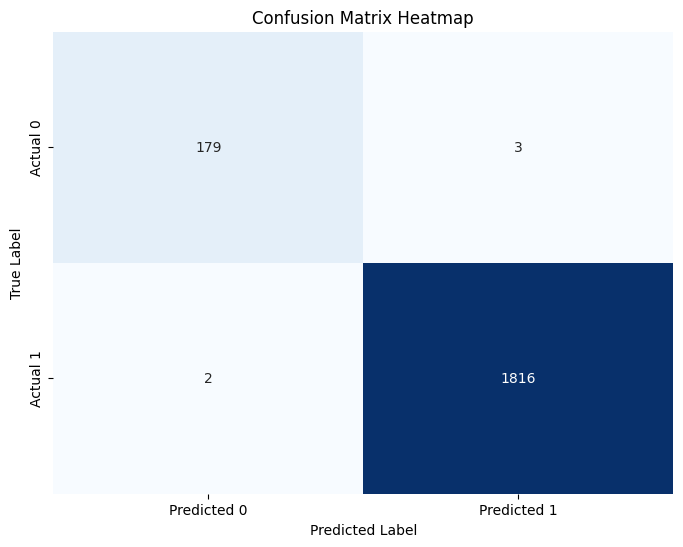

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, ypred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

### ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) is a measure of the ability of a classifier to distinguish between classes and is used as a summary of the ROC curve.

In [18]:
from sklearn.metrics import roc_curve, auc

# Get probability predictions for the positive class
y_pred_proba = model.predict_proba(x_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

print(f'AUC Score: {roc_auc:.4f}')

AUC Score: 1.0000


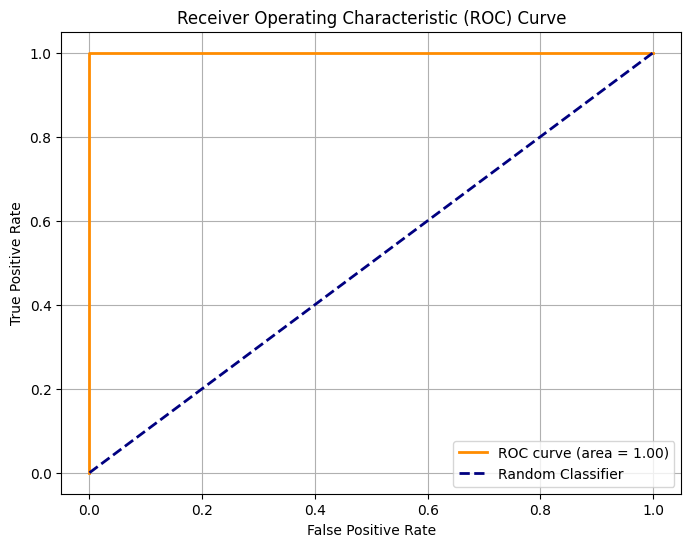

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Cross-Validation

Cross-validation is a technique used to assess how the results of a statistical analysis will generalize to an independent data set. It is mainly used in settings where the goal is prediction, and one wants to estimate how accurately a predictive model will perform in practice. In a prediction problem, a model is usually given a dataset of known data on which training is run (training dataset) and a dataset of unknown data (or first seen data) against which the model is tested (testing dataset).

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize Stratified K-Fold Cross-Validation
# n_splits=5 means the data will be split into 5 folds
# shuffle=True ensures the data is shuffled before splitting
# random_state for reproducibility
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get accuracy scores for each fold
cv_scores = cross_val_score(model, x, y, cv=skf, scoring='accuracy')

print(f'Cross-validation accuracy scores: {cv_scores}')
print(f'Mean cross-validation accuracy: {np.mean(cv_scores):.4f}')
print(f'Standard deviation of cross-validation accuracy: {np.std(cv_scores):.4f}')

Cross-validation accuracy scores: [0.999  0.9965 0.9965 0.998  0.996 ]
Mean cross-validation accuracy: 0.9972
Standard deviation of cross-validation accuracy: 0.0011


### Hyperparameter Tuning with GridSearchCV

Hyperparameter tuning is the process of choosing a set of optimal hyperparameters for a learning algorithm. A hyperparameter is a configuration variable that is external to the model and whose value cannot be estimated from data. GridSearchCV is a common method for hyperparameter tuning that exhaustively searches over a specified parameter grid.

In [21]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Initialize GridSearchCV
# model: the estimator object (LogisticRegression)
# param_grid: dictionary of hyperparameters to search
# cv: number of folds for cross-validation
# scoring: metric to evaluate the model (e.g., 'accuracy')
# verbose: controls the verbosity: the higher, the more messages
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(x_train, y_train)

# Print the best parameters and best score
print(f'Best parameters found: {grid_search.best_params_}')
print(f'Best cross-validation accuracy: {grid_search.best_score_:.4f}')

# Get the best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found: {'C': 10, 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.9994


### Evaluate the Tuned Model

After finding the best hyperparameters, we evaluate the tuned model on the test set to confirm its performance.

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions with the best model
y_pred_tuned = best_model.predict(x_test)

# Evaluate the tuned model
print(f'Tuned Model Accuracy Score: {accuracy_score(y_test, y_pred_tuned):.4f}')
print('\nTuned Model Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_tuned))
print('\nTuned Model Classification Report:')
print(classification_report(y_test, y_pred_tuned))

Tuned Model Accuracy Score: 0.9990

Tuned Model Confusion Matrix:
[[ 181    1]
 [   1 1817]]

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       182
           1       1.00      1.00      1.00      1818

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

